# Catalog Demo

## Example Map

This notebook demonstrates using TECA BARD v1.0.1 data from [the ARTMIP Tier 1 dataset](https://doi.org/10.5065/D62R3QFS)

In [1]:
""" Import libraries """
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import xarray as xr
import cartopy

In [ ]:
""" Open the ARTMIP sample file that comes with this repository. """
# downloadable from https://github.com/taobrienlbl/artmip-publish-teca-bard-v1.0.1/raw/refs/heads/main/MERRA2.ar_tag.teca_bard_v1.0.1.3hourly.2017.nc
artmip_file = "MERRA2.ar_tag.teca_bard_v1.0.1.3hourly.2017.nc"
bard_xr = xr.open_dataset(artmip_file)
bard_xr


<xarray.Dataset> Size: 2MB
Dimensions:              (time: 2, lat: 361, lon: 576, dim_ar_count: 1024,
                          dim_parameter_table_row: 1024)
Coordinates:
  * lat                  (lat) float64 3kB -90.0 -89.5 -89.0 ... 89.0 89.5 90.0
  * lon                  (lon) float64 5kB -180.0 -179.4 -178.8 ... 178.8 179.4
  * time                 (time) datetime64[ns] 16B 2017-01-01 2017-01-01T03:0...
Dimensions without coordinates: dim_ar_count, dim_parameter_table_row
Data variables:
    ar_binary_tag        (time, lat, lon) int8 416kB dask.array<chunksize=(2, 361, 576), meta=np.ndarray>
    ar_count             (time, dim_ar_count) int32 8kB dask.array<chunksize=(2, 1024), meta=np.ndarray>
    ar_probability       (time, lat, lon) float32 2MB dask.array<chunksize=(2, 361, 576), meta=np.ndarray>
    parameter_table_row  (time, dim_parameter_table_row) int32 8kB dask.array<chunksize=(2, 1024), meta=np.ndarray>
Attributes:
    TECA_version:   4.1.0
    TECA_app_name:  teca_bayesian_ar_detect
    NCO:            netCDF Operators version 5.2.4 (Homepage = http://nco.sf....
    history:        Fri Apr 18 10:18:09 2025: ncks -d time,0,1 MERRA2.ar_tag....

Note that TECA BARD has an extra variable that other ARTMIP algorithms do not: `ar_probability`.  This represents the probability (ranging 0 to 1) in each gridcell that an AR is present at that time.  The `ar_binary_tag` variable was created by thresholding the `ar_probability` variable at 2/3; hence the `ar_binary_tag` represents *likely* AR conditions in a grid cell.

Let's plot this.

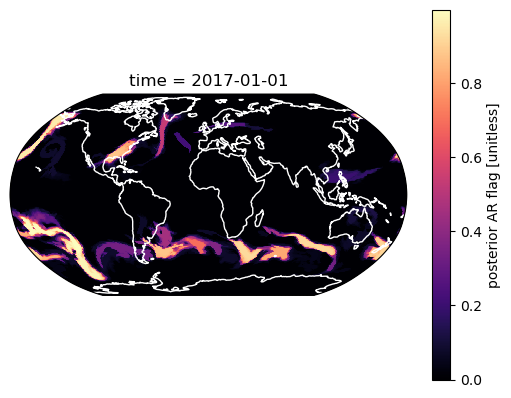

In [3]:
""" Plot AR probability. """
# get the first timestep
ar_prob = bard_xr['ar_probability'].isel(time = 0)

fig, ax = plt.subplots(subplot_kw=dict(projection = cartopy.crs.Robinson()))

ar_prob.plot(ax = ax, transform = cartopy.crs.PlateCarree(), cmap = 'magma')

ax.coastlines(color = 'white')

plt.show()

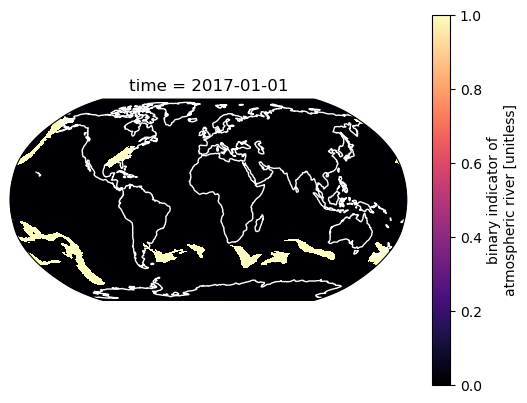

In [4]:
""" Plot AR binary tag """
# get the first timestep
ar_tag = bard_xr['ar_binary_tag'].isel(time = 0)

fig, ax = plt.subplots(subplot_kw=dict(projection = cartopy.crs.Robinson()))

ar_tag.plot(ax = ax, transform = cartopy.crs.PlateCarree(), cmap = 'magma')

ax.coastlines(color = 'white')

plt.show()